# Тестирование алгоритмов на синтетических датасетах

**Датасеты:** numpy_linear, numpy_timeseries, sklearn_blobs, sklearn_classification, sklearn_regression_style, scipy_mixed


In [4]:
import sys, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score,
    normalized_mutual_info_score, fowlkes_mallows_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score)
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from data_generator.habr_synthetic import all_habr_datasets
from algorithms import DBSCANWrapper, HDBSCANWrapper, DPCWrapper, RDDACWrapper, CKDPCWrapper

In [6]:
DATASETS = all_habr_datasets()

rows = []
for ds in DATASETS:
    X_s = MinMaxScaler().fit_transform(ds.X)
    nbrs = NearestNeighbors(n_neighbors=3).fit(X_s)
    d, _ = nbrs.kneighbors(X_s)
    sizes = np.bincount(ds.y_true)
    rows.append({'Dataset': ds.name.replace('habr_',''),
                 'n': ds.X.shape[0], 'features': ds.X.shape[1],
                 'k_true': len(sizes), 'class_sizes': str(sizes.tolist())})
pd.DataFrame(rows).set_index('Dataset')

,n,features,k_true,class_sizes
Dataset,,,,
numpy_linear,150,2,3,"[50, 50, 50]"
numpy_timeseries,150,2,3,"[50, 50, 50]"
sklearn_blobs,300,2,3,"[100, 100, 100]"
sklearn_regression_style,150,2,3,"[50, 50, 50]"
scipy_mixed,150,2,3,"[50, 50, 50]"


In [7]:
ALG_NAMES = ['DBSCAN','HDBSCAN','DPC','RD-DAC','CKDPC']
ALG_CLASSES = {
    'DBSCAN':  DBSCANWrapper,
    'HDBSCAN': HDBSCANWrapper,
    'DPC':     DPCWrapper,
    'RD-DAC':  RDDACWrapper,
    'CKDPC':   CKDPCWrapper,
}

In [8]:
def _arange(a, b, step, dec=3):
    return [round(float(v), dec) for v in np.arange(a, b + step*0.5, step)]


def compute_all_metrics(X, labels, y_true):
    labels  = np.asarray(labels, dtype=int)
    y_true  = np.asarray(y_true, dtype=int)
    mask_nn = labels != -1
    k_found   = len(set(labels[mask_nn].tolist())) if mask_nn.any() else 0
    noise_pct = float((~mask_nn).sum()) / len(labels) * 100

    if k_found >= 2:
        ari = float(adjusted_rand_score(y_true, labels))
        ami = float(adjusted_mutual_info_score(y_true, labels))
        nmi = float(normalized_mutual_info_score(y_true, labels))
        fmi = float(fowlkes_mallows_score(y_true, labels))
    elif k_found == 1:
        ari = ami = nmi = fmi = 0.0
    else:
        ari = ami = nmi = fmi = float('nan')

    X_sub, l_sub = X[mask_nn], labels[mask_nn]
    if mask_nn.sum() >= 2 and len(np.unique(l_sub)) >= 2:
        try:    sc  = float(silhouette_score(X_sub, l_sub))
        except: sc  = float('nan')
        try:    chi = float(calinski_harabasz_score(X_sub, l_sub))
        except: chi = float('nan')
        try:    dbi = float(davies_bouldin_score(X_sub, l_sub))
        except: dbi = float('nan')
    else:
        sc = chi = dbi = float('nan')

    return dict(k_found=k_found, noise_pct=noise_pct,
                ARI=ari, AMI=ami, NMI=nmi, FMI=fmi,
                SC=sc, CHI=chi, DBI=dbi)


def _eps_grid(X, n_steps=40):
    X_s = MinMaxScaler().fit_transform(X)
    nbrs = NearestNeighbors(n_neighbors=3).fit(X_s)
    d, _ = nbrs.kneighbors(X_s)
    d_med = float(np.median(d[:, 1]))
    d_90  = float(np.percentile(d[:, 1], 90))
    eps_min  = max(0.005, round(d_med * 0.2, 3))
    eps_max  = round(d_90 * 5.0, 3)
    eps_step = max(0.005, round((eps_max - eps_min) / n_steps, 3))
    return _arange(eps_min, eps_max, eps_step)


def get_param_grid(alg_name, X, k_true):
    n = X.shape[0]
    if alg_name == 'DBSCAN':
        return {'eps':         _eps_grid(X, n_steps=40),
                'min_samples': list(range(1, min(n//5, 20)))}
    if alg_name == 'HDBSCAN':
        return {'min_cluster_size': list(range(2, min(n//3, 30))),
                'min_samples':      list(range(1, 10))}
    if alg_name == 'DPC':
        return {'percent': _arange(0.5, 20.0, 0.5)}
    if alg_name == 'RD-DAC':
        return {'k': list(range(2, min(n-1, 25)))}
    if alg_name == 'CKDPC':
        return {'alpha':   _arange(0.01, 10.0, 0.05),
                'percent': _arange(0.5, 20.0, 0.5)}
    return {}


def grid_search(alg_class, param_grid, X, y_true):
    from itertools import product as iproduct
    keys   = list(param_grid.keys())
    combos = list(iproduct(*[param_grid[k] for k in keys])) if keys else [()]
    best_ari = -2.0
    best_mets = best_params = best_labels = best_alg = None
    for combo in combos:
        params = dict(zip(keys, combo))
        try:
            alg    = alg_class(**params)
            labels = np.asarray(alg.fit_predict(X), dtype=int)
            mets   = compute_all_metrics(X, labels, y_true)
            ari    = mets['ARI'] if (mets['ARI'] == mets['ARI']) else -1.0
            if ari > best_ari:
                best_ari = ari; best_mets = mets
                best_params = params; best_labels = labels; best_alg = alg
        except Exception:
            pass
    if best_mets is None:
        best_mets   = dict(k_found=0, noise_pct=100.0,
                           ARI=float('nan'), AMI=float('nan'), NMI=float('nan'),
                           FMI=float('nan'), SC=float('nan'), CHI=float('nan'), DBI=float('nan'))
        best_labels = np.zeros(len(y_true), dtype=int)
    return best_mets, best_params, best_labels, best_alg


def _fmt(v, key=''):
    if isinstance(v, float) and v != v: return '-'
    if key in ('ARI','AMI','NMI','FMI','SC','DBI'): return f'{v:.4f}'
    if key == 'CHI': return f'{v:.1f}'
    return str(v)

In [9]:
ALL_RESULTS = {}

for ds in DATASETS:
    X, y   = ds.X, ds.y_true
    k_true = len(np.unique(y))
    dname  = ds.name.replace('habr_', '')
    print(f'\n{dname}  [{X.shape[0]} x {X.shape[1]}]  k_true={k_true}')

    rows = {}
    for alg_name in ALG_NAMES:
        t0    = time.time()
        pgrid = get_param_grid(alg_name, X, k_true)
        mets, best_p, best_labels, best_alg = grid_search(ALG_CLASSES[alg_name], pgrid, X, y)
        elapsed = time.time() - t0
        rows[alg_name] = {**mets, 'best_params': best_p or {}, 'labels': best_labels, 'alg': best_alg}
        ari_s = f'{mets["ARI"]:.4f}' if mets["ARI"]==mets["ARI"] else '-'
        p_str = ', '.join(f'{k}={v}' for k,v in (best_p or {}).items())
        print(f'  {alg_name:<8}  k={mets["k_found"]:2d}  noise={mets["noise_pct"]:5.1f}%  '
              f'ARI={ari_s:<7}  ({elapsed:.1f}s)  [{p_str}]')

    ALL_RESULTS[dname] = {'rows': rows, 'X': X, 'y': y, 'k_true': k_true}


numpy_linear  [150 x 2]  k_true=3
  DBSCAN    k= 3  noise=  0.0%  ARI=1.0000   (2.4s)  [eps=0.085, min_samples=1]
  HDBSCAN   k= 3  noise=  0.0%  ARI=1.0000   (1.1s)  [min_cluster_size=2, min_samples=4]
  DPC       k= 4  noise=  0.0%  ARI=0.8941   (0.1s)  [percent=12.0]
  RD-DAC    k= 6  noise=  0.0%  ARI=0.6722   (0.1s)  [k=24]
  CKDPC     k= 4  noise=  8.0%  ARI=0.8671   (44.6s)  [alpha=0.11, percent=18.5]

numpy_timeseries  [150 x 2]  k_true=3
  DBSCAN    k= 3  noise=  0.0%  ARI=1.0000   (1.3s)  [eps=0.13, min_samples=1]
  HDBSCAN   k= 3  noise=  0.0%  ARI=1.0000   (1.1s)  [min_cluster_size=2, min_samples=8]
  DPC       k= 3  noise=  0.0%  ARI=1.0000   (0.1s)  [percent=5.0]
  RD-DAC    k= 5  noise=  0.0%  ARI=0.8267   (0.1s)  [k=11]
  CKDPC     k= 3  noise=  6.7%  ARI=0.8970   (46.5s)  [alpha=0.01, percent=5.5]

sklearn_blobs  [300 x 2]  k_true=3
  DBSCAN    k= 3  noise=  0.0%  ARI=1.0000   (0.9s)  [eps=0.05, min_samples=1]
  HDBSCAN   k= 3  noise=  0.0%  ARI=1.0000   (1.5s)  [min_

In [10]:
COLS = ['k_found','noise_pct','ARI','AMI','NMI','FMI','SC','CHI','DBI']
COL_LABELS = ['k','noise%','ARI','AMI','NMI','FMI','SC','CHI','DBI']

for dname, res in ALL_RESULTS.items():
    table = []
    for alg in ALG_NAMES:
        m     = res['rows'][alg]
        p_str = ', '.join(f'{k}={v}' for k,v in m.get('best_params',{}).items())
        row   = [alg] + [_fmt(m.get(c, float('nan')), c) for c in COLS] + [p_str]
        table.append(row)
    df = pd.DataFrame(table, columns=['Algorithm'] + COL_LABELS + ['best_params'])
    df = df.set_index('Algorithm')
    print(f'\n{dname}  (k_true={res["k_true"]})')
    display(df)


numpy_linear  (k_true=3)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,best_params
Algorithm,,,,,,,,,,
DBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.6308,479.5,0.5502,"eps=0.085, min_samples=1"
HDBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.6308,479.5,0.5502,"min_cluster_size=2, min_samples=4"
DPC,4,0.0,0.8941,0.9160,0.9175,0.9289,0.5937,425.9,0.5171,percent=12.0
RD-DAC,6,0.0,0.6722,0.7813,0.7868,0.7774,0.5921,471.9,0.5072,k=24
CKDPC,4,8.0,0.8671,0.8375,0.8413,0.9102,0.3838,349.6,0.7243,"alpha=0.11, percent=18.5"



numpy_timeseries  (k_true=3)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,best_params
Algorithm,,,,,,,,,,
DBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.4137,119.1,1.1592,"eps=0.13, min_samples=1"
HDBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.4137,119.1,1.1592,"min_cluster_size=2, min_samples=8"
DPC,3,0.0,1.0000,1.0000,1.0000,1.0000,0.4137,119.1,1.1592,percent=5.0
RD-DAC,5,0.0,0.8267,0.8578,0.8609,0.8834,0.4176,112.5,0.6909,k=11
CKDPC,3,6.666666666666667,0.8970,0.8674,0.8697,0.9306,0.4331,123.4,1.0892,"alpha=0.01, percent=5.5"



sklearn_blobs  (k_true=3)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,best_params
Algorithm,,,,,,,,,,
DBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.8923,17477.7,0.1512,"eps=0.05, min_samples=1"
HDBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.8923,17477.7,0.1512,"min_cluster_size=2, min_samples=3"
DPC,4,0.0,0.9901,0.9852,0.9853,0.9934,0.5769,11687.6,0.5689,percent=15.0
RD-DAC,4,0.0,0.9853,0.9798,0.9800,0.9902,0.7643,12331.3,0.2855,k=2
CKDPC,3,7.666666666666666,0.8803,0.8500,0.8513,0.9194,0.9047,20906.3,0.1355,"alpha=0.11, percent=16.5"



sklearn_regression_style  (k_true=3)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,best_params
Algorithm,,,,,,,,,,
DBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.6218,452.2,0.5788,"eps=0.1, min_samples=1"
HDBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.6218,452.2,0.5788,"min_cluster_size=2, min_samples=4"
DPC,4,0.0,0.8991,0.9186,0.9200,0.9323,0.5742,377.7,0.5498,percent=11.0
RD-DAC,7,0.0,0.5636,0.7340,0.7416,0.7002,0.5393,605.1,0.5374,k=7
CKDPC,3,6.0,0.9068,0.8756,0.8778,0.9372,0.6403,479.4,0.5475,"alpha=0.01, percent=7.5"



scipy_mixed  (k_true=3)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,best_params
Algorithm,,,,,,,,,,
DBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.8723,2597.3,0.1932,"eps=0.105, min_samples=1"
HDBSCAN,3,0.0,1.0000,1.0000,1.0000,1.0000,0.8723,2597.3,0.1932,"min_cluster_size=2, min_samples=3"
DPC,4,0.0,0.9804,0.9747,0.9752,0.9869,0.6172,1730.5,0.6299,percent=14.5
RD-DAC,4,0.0,0.9377,0.9410,0.9421,0.9582,0.6407,1802.9,0.6002,k=4
CKDPC,4,6.666666666666667,0.9082,0.9153,0.9173,0.9384,0.6164,2207.5,0.5778,"alpha=0.56, percent=12.0"


In [11]:
TICKS_01 = [round(i * 0.1, 1) for i in range(11)]


def _cluster_colors(labels):
    ids = sorted(set(labels.tolist()))
    clust_ids = [i for i in ids if i != -1]
    n_c = len(clust_ids)
    cmap = plt.get_cmap('tab10') if n_c <= 10 else plt.get_cmap('tab20')
    return {c: cmap(j / max(n_c, 1)) for j, c in enumerate(clust_ids)}


def _plot_ax(ax, X_2d, labels, alg=None, title=''):
    color_map  = _cluster_colors(labels)
    mask_noise = labels == -1
    mask_clust = ~mask_noise
    s = max(10, min(50, int(1500 / len(labels))))

    if mask_clust.any():
        colors = np.array([color_map[l] for l in labels[mask_clust]])
        ax.scatter(X_2d[mask_clust, 0], X_2d[mask_clust, 1],
                   c=colors, s=s, linewidths=0, zorder=2)

    if mask_noise.any():
        ax.scatter(X_2d[mask_noise, 0], X_2d[mask_noise, 1],
                   color='#888888', marker='x', s=s+10, linewidths=0.9, zorder=3)

    if alg is not None:
        centers = getattr(alg, 'centers_', None)
        if centers is not None and len(centers) > 0:
            ax.scatter(X_2d[centers, 0], X_2d[centers, 1],
                       marker='*', s=220, c='red', zorder=5,
                       linewidths=0.5, edgecolors='darkred')

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks(TICKS_01)
    ax.set_yticks(TICKS_01)
    ax.tick_params(labelsize=5.5, length=2, pad=1)
    ax.grid(True, color='#cccccc', linewidth=0.35, linestyle='--', zorder=0)
    for sp in ax.spines.values():
        sp.set_linewidth(0.4)
    ax.set_title(title, fontsize=8, pad=4)
    ax.set_xlabel('x', fontsize=7, labelpad=2)
    ax.set_ylabel('y', fontsize=7, labelpad=2)


def plot_habr_results(dname, res, save_path=None):
    X, y   = res['X'], res['y']
    rows   = res['rows']
    X_2d   = MinMaxScaler().fit_transform(X)

    n_cols  = 3
    n_items = len(ALG_NAMES) + 1
    n_rows  = int(np.ceil(n_items / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * 3.8, n_rows * 3.6),
                              constrained_layout=True)
    axes = axes.ravel()

    _plot_ax(axes[0], X_2d, y, title=f'{dname}')
    axes[0].title.set_fontweight('bold')

    for idx, alg_name in enumerate(ALG_NAMES):
        m   = rows[alg_name]
        lbl = m['labels']
        alg = m.get('alg')
        ari_val = m['ARI']
        ari_str = f'{ari_val:.3f}' if (isinstance(ari_val, float) and ari_val==ari_val) else '-'
        _plot_ax(axes[idx+1], X_2d, lbl, alg=alg,
                 title=f'{alg_name}  k={m["k_found"]}  ARI={ari_str}')

    for ax in axes[n_items:]:
        ax.set_visible(False)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

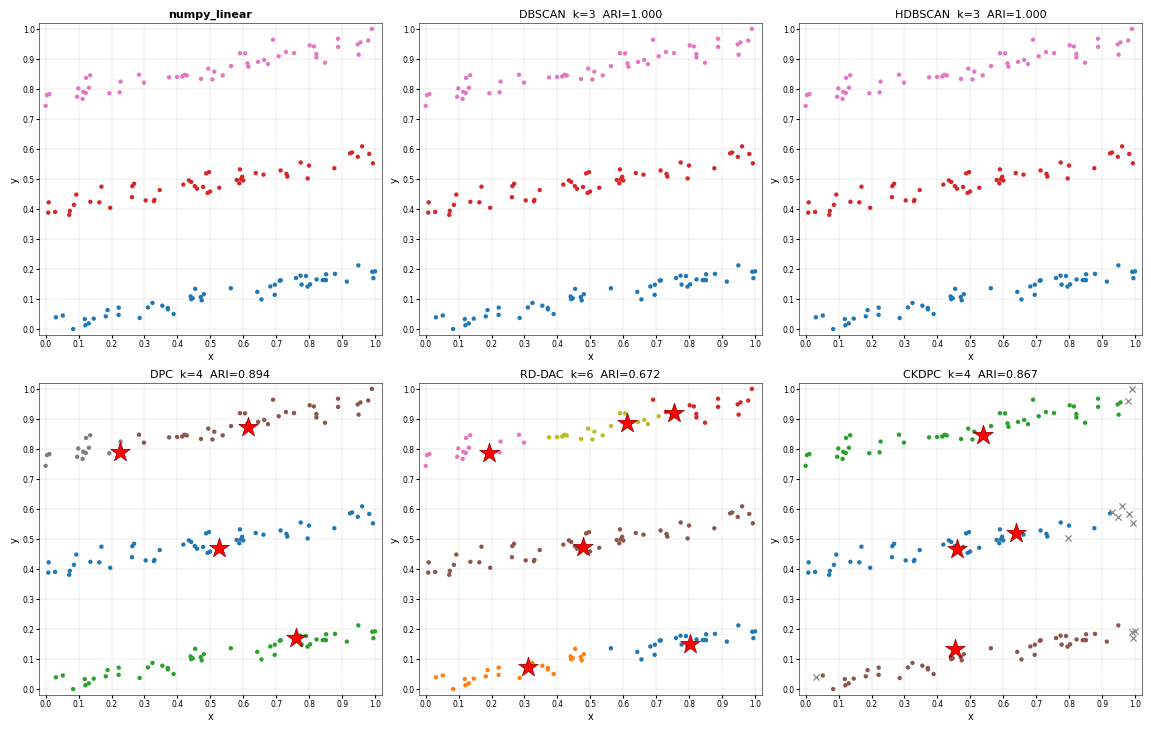

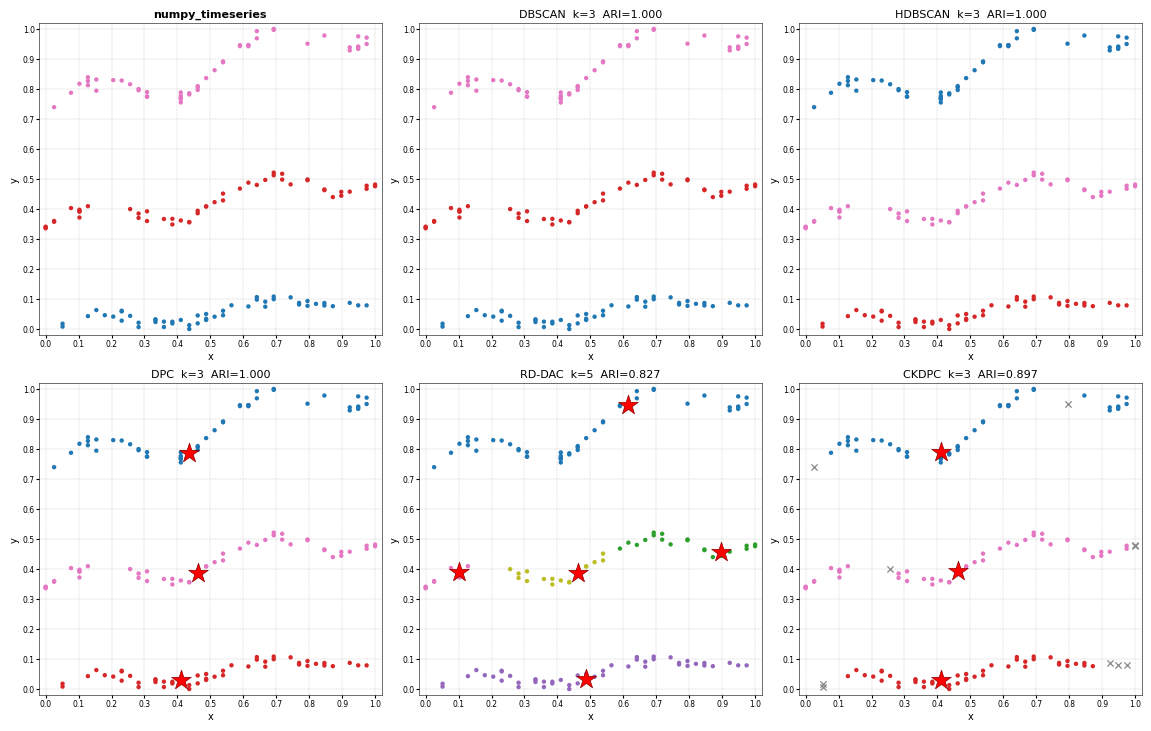

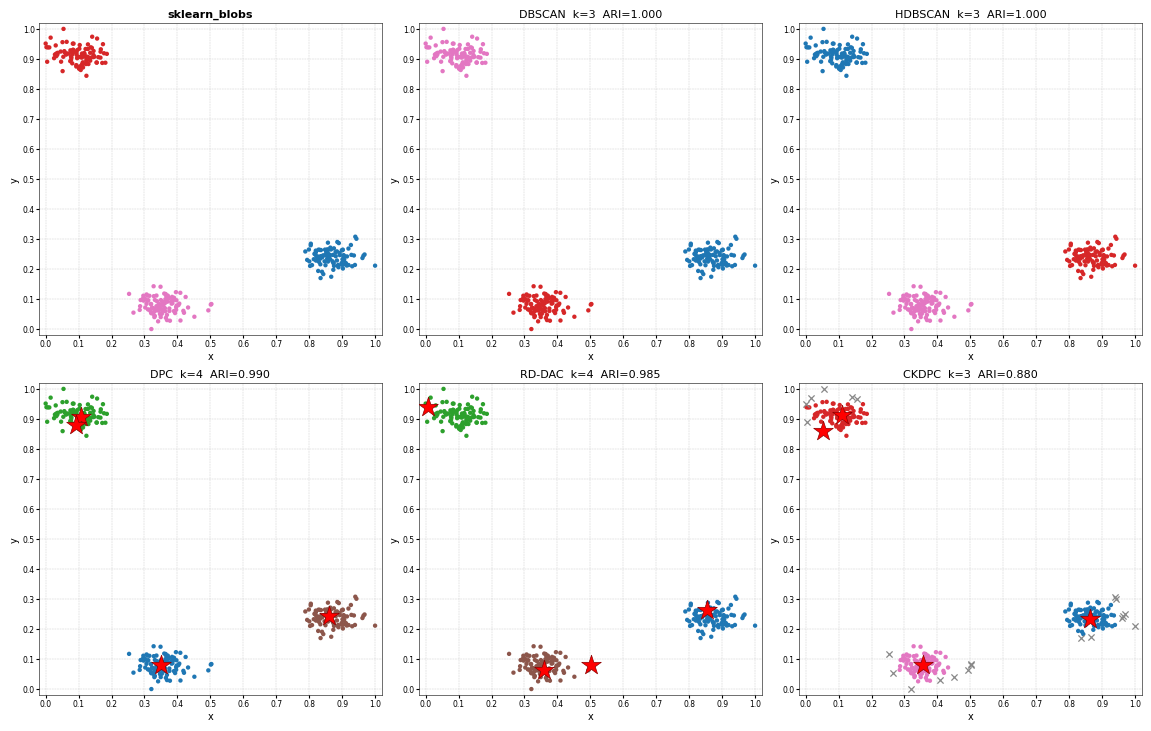

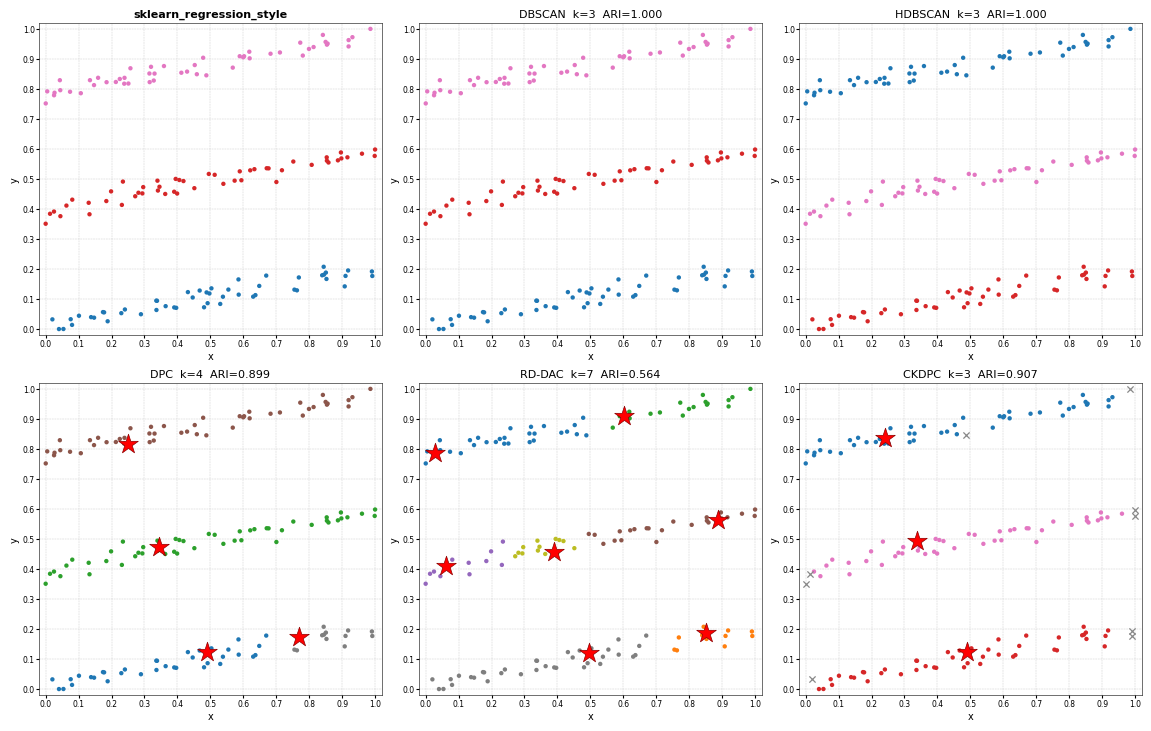

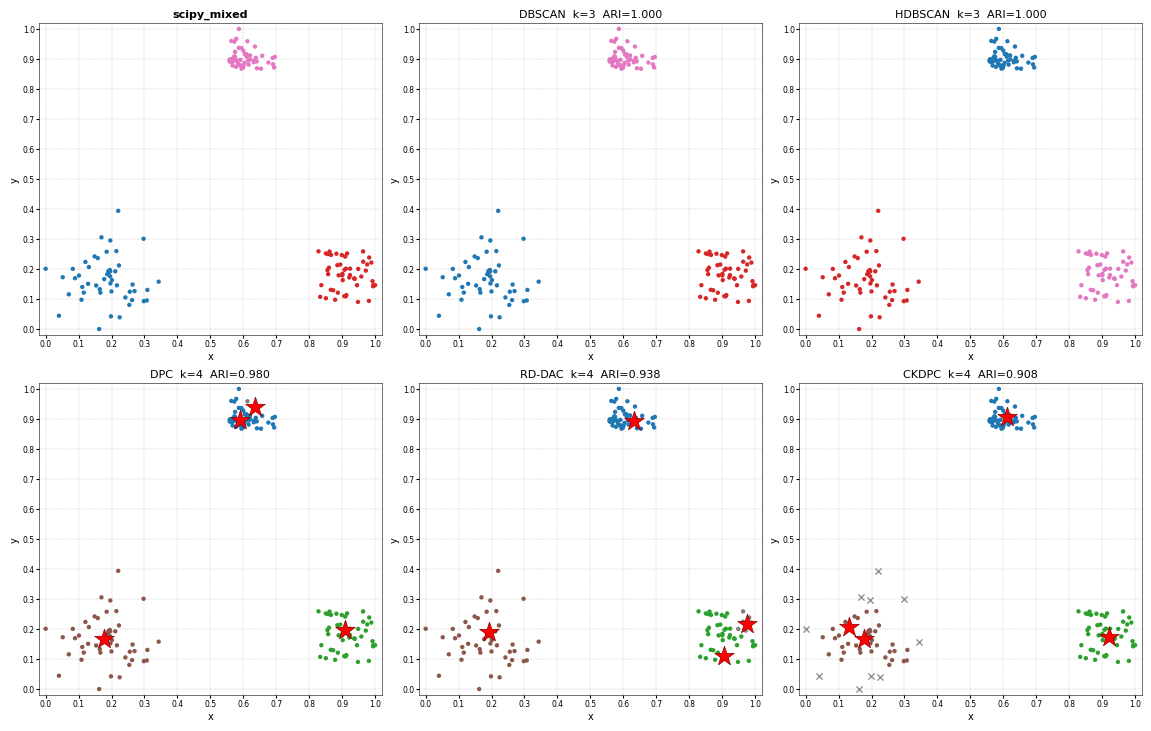

In [12]:
import os
os.makedirs('../results/habr_figures', exist_ok=True)

for dname, res in ALL_RESULTS.items():
    plot_habr_results(dname, res,
                      save_path=f'../results/habr_figures/{dname}.png')

In [ ]:
summary = []
for dname, res in ALL_RESULTS.items():
    for alg in ALG_NAMES:
        m = res['rows'][alg]
        ari = m['ARI'] if (isinstance(m['ARI'], float) and m['ARI']==m['ARI']) else None
        summary.append({'Dataset': dname, 'k_true': res['k_true'],
                        'Algorithm': alg, 'k_found': m['k_found'],
                        'noise%': round(m['noise_pct'], 1),
                        'ARI': round(ari, 4) if ari is not None else None,
                        'NMI': round(m['NMI'], 4) if (isinstance(m['NMI'],float) and m['NMI']==m['NMI']) else None,
                        'AMI': round(m['AMI'], 4) if (isinstance(m['AMI'],float) and m['AMI']==m['AMI']) else None,
                        'FMI': round(m['FMI'], 4) if (isinstance(m['FMI'],float) and m['FMI']==m['FMI']) else None})
                        
df_sum = pd.DataFrame(summary)
df_pivot = df_sum.pivot_table(
    index='Algorithm',
    columns='Dataset',
    values=['ARI', 'AMI', 'NMI', 'FMI'],
    aggfunc='first'
)

df_pivot = df_pivot.swaplevel(axis=1).sort_index(axis=1)


display(df_pivot.style
    .format('{:.4f}', na_rep='-')
    .background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1)
    .set_caption('Внешние метрики')
)